# Pronósticos basados en series de tiempo

## Dario Esteban Botina
## Diego Fernando Leon
## Universidad Javeriana-Cali
## estebanbotina94@gmail.com
## shaggypatas@gmail.com


## **1. Carga de paquetes**

In [83]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [40]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



## Tasa de desempleo

(222, 4)


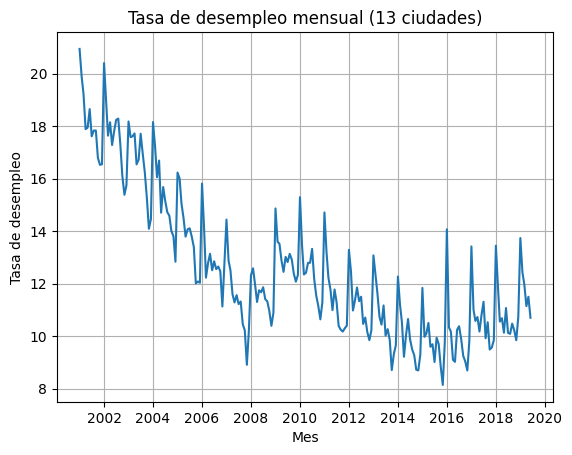

In [41]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## Personas ocupadas

(222, 4)


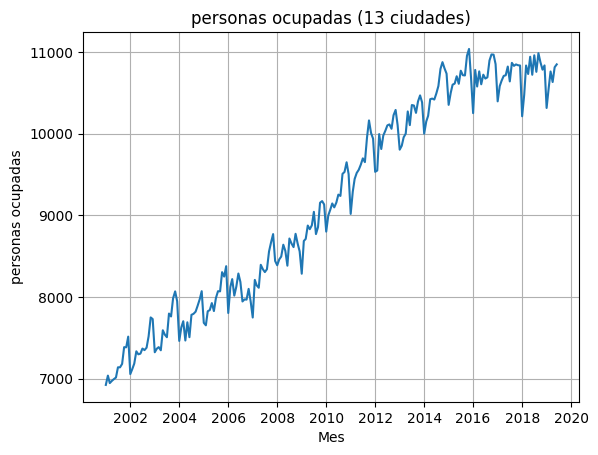

In [42]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("personas ocupadas (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("personas ocupadas")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

## **3. Encontrando los componentes de una serie de tiempo**

En algunas ocasiones puede ser útil empezar nuestro análisis descomponiendo la serie de tiempo en sus componentes: **tendencia**, **estacionalidad** y **componente puramente aleatorio**. Una forma de hacer esto es empleando la función seasonal_decompose.

## Tasa de desempleo

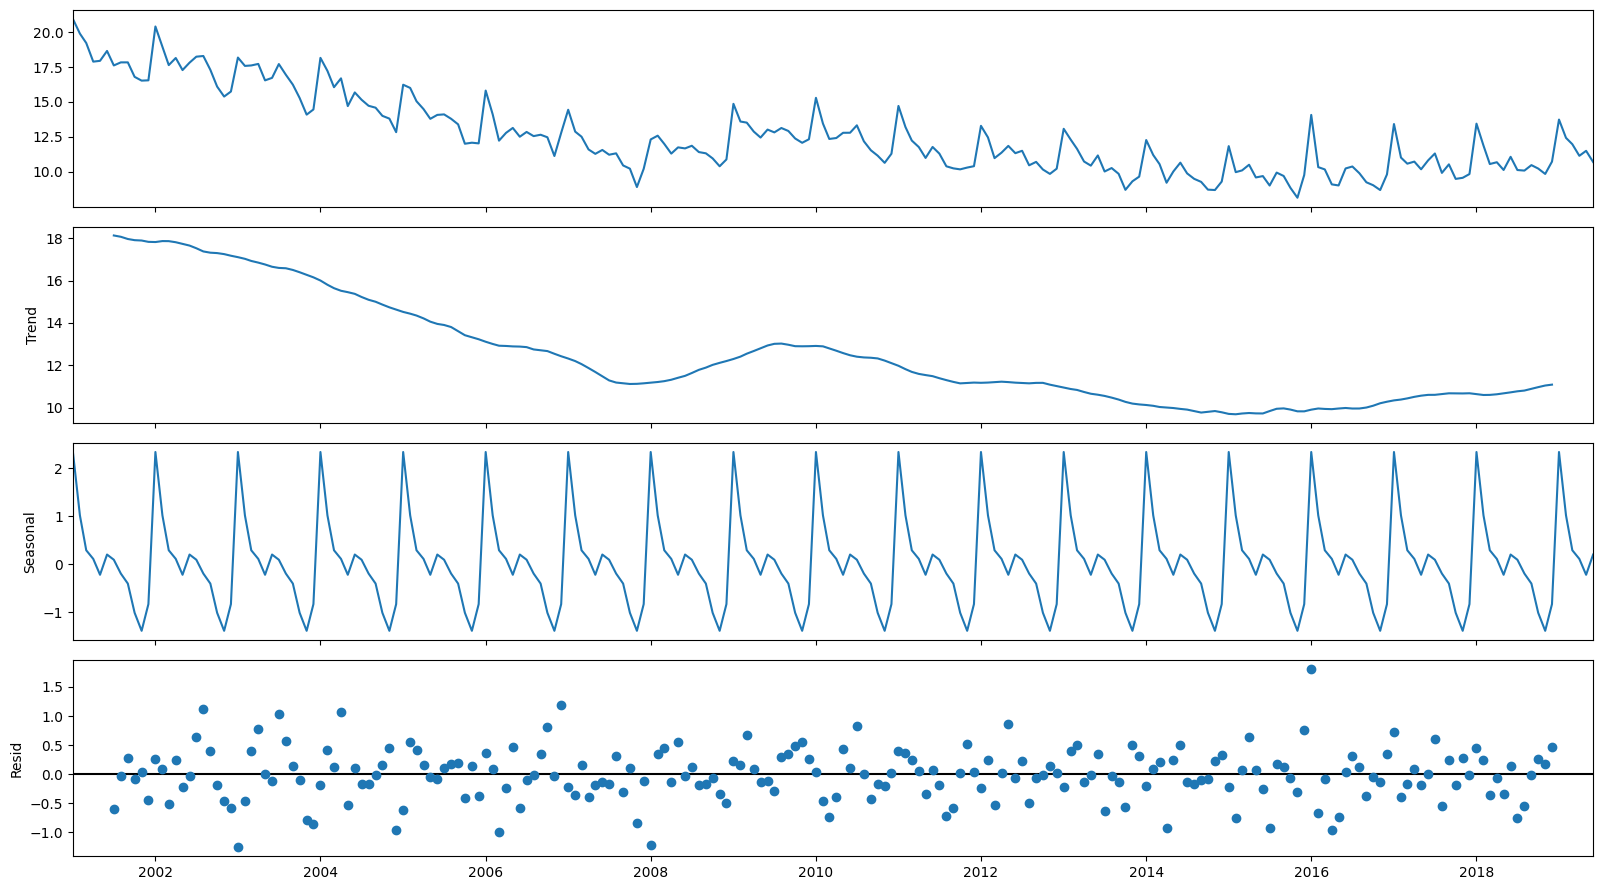

In [43]:
td_componentes = seasonal_decompose(data[["TD_13ciudades"]],model="additive")
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

## Personas ocupadas

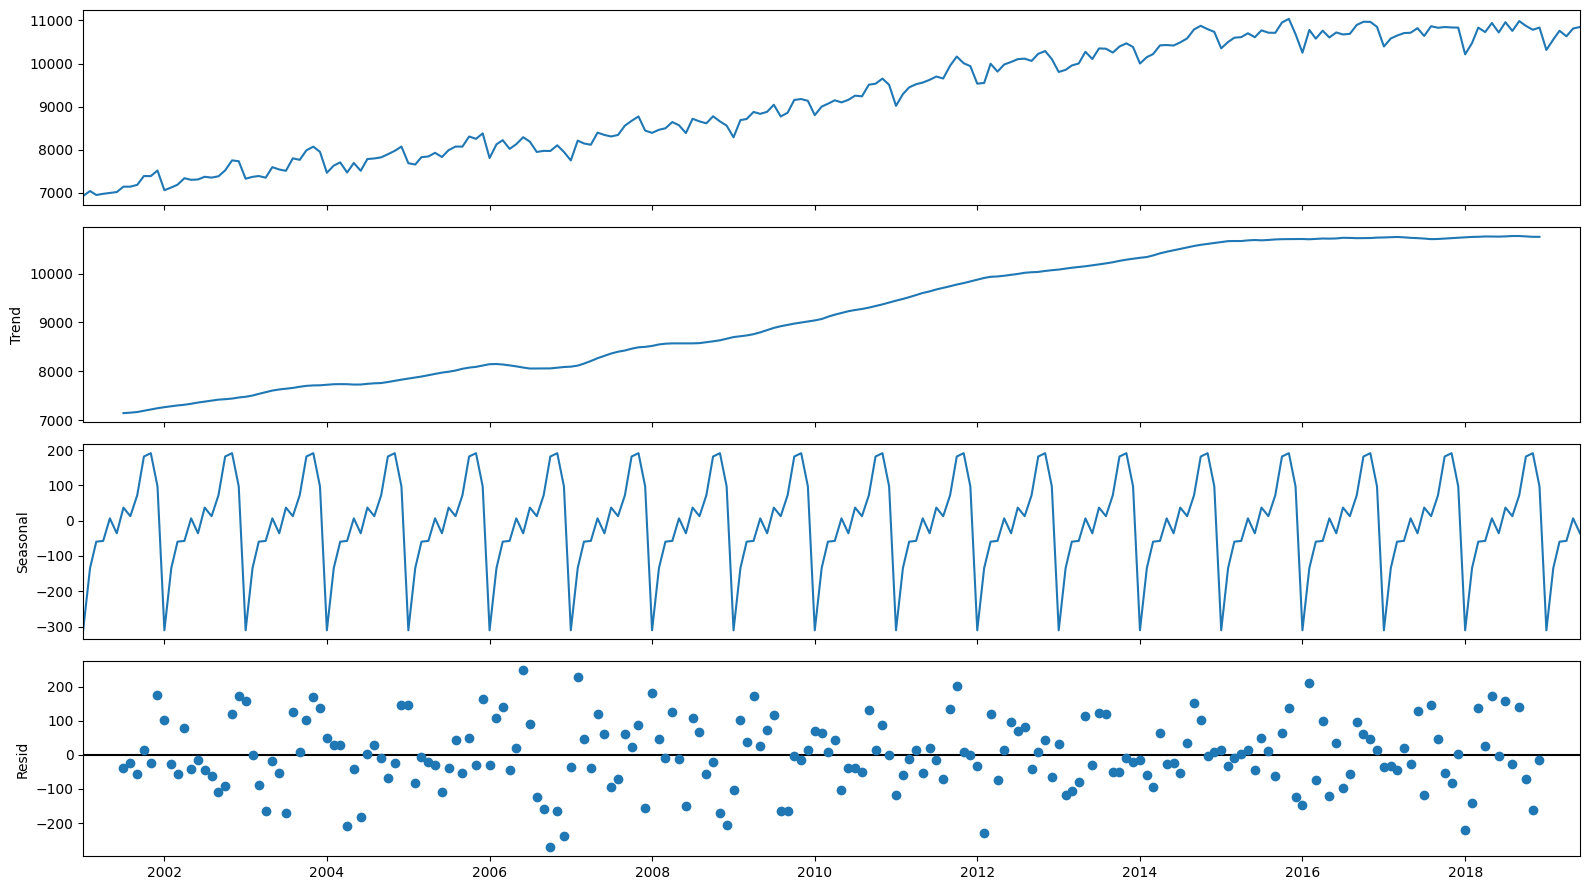

In [44]:
Ocupados_componentes = seasonal_decompose(data[["Ocupados"]],model="additive")
fig = Ocupados_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

Asi se extrae cada elemento de la descomposición de la serie.

In [45]:
# tasa de desampleo

td_componentes.seasonal
#td_componentes.trend
#td_componentes.resid

,seasonal
mes,
2001-01-01,2.337888
2001-02-01,1.017106
2001-03-01,0.290193
2001-04-01,0.110715
2001-05-01,-0.220208
...,...
2019-02-01,1.017106
2019-03-01,0.290193
2019-04-01,0.110715


In [47]:
#personas ocupadas

Ocupados_componentes.seasonal
#Ocupados_componentes.trend
#Ocupados_componentes.resid

,seasonal
mes,
2001-01-01,-310.570069
2001-02-01,-134.331549
2001-03-01,-59.585841
2001-04-01,-57.385905
2001-05-01,6.435912
...,...
2019-02-01,-134.331549
2019-03-01,-59.585841
2019-04-01,-57.385905


Podemos observar el componente estacional marcado en la serie, una tendencia no lineal de los datos y la parte aleatoria.

Es importante mencionar que esta descomposición se emplea solo como referencia para iniciar el análisis.

Antes de entrar a trabajar con los métodos de suavizamiento, vale la pena anotar que una forma sencilla y rápida para quitar el componente estacional (desestacionalizar) es restarle a la serie el componente estacional encontrado en la descomposición. Es decir,

# Grafica con y sin estacionalidad tasa desempleo

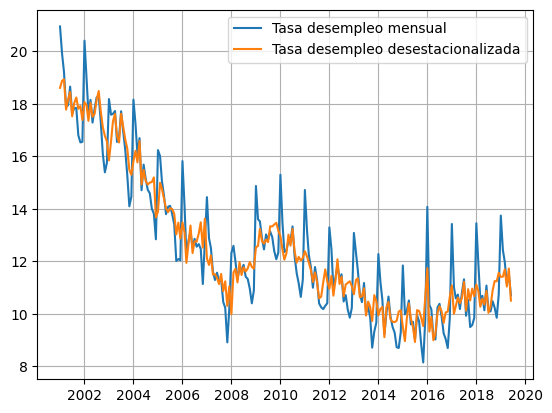

In [48]:
td_desestacionalizada = data["TD_13ciudades"]-td_componentes.seasonal

plt.plot(data[["TD_13ciudades"]],label="Tasa desempleo mensual")
plt.plot(td_desestacionalizada,label="Tasa desempleo desestacionalizada")
plt.legend()
plt.grid()
plt.show()


# Grafica con y sin estacionalidad personas ocupadas

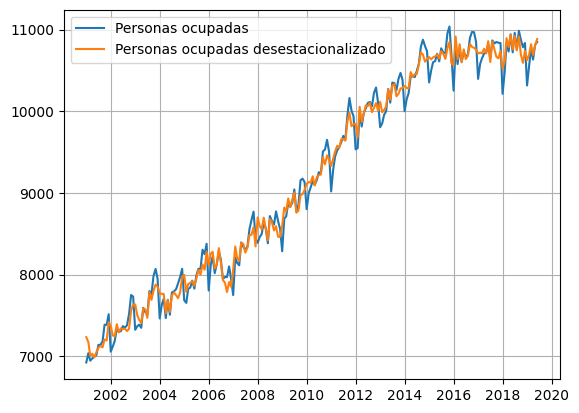

In [49]:
Ocupados_desestacionalizada = data["Ocupados"]-Ocupados_componentes.seasonal

plt.plot(data[["Ocupados"]],label="Personas ocupadas")
plt.plot(Ocupados_desestacionalizada,label="Personas ocupadas desestacionalizado")
plt.legend()
plt.grid()
plt.show()

## **4. Protocolo de evaluación**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

## Tasa de desempleo

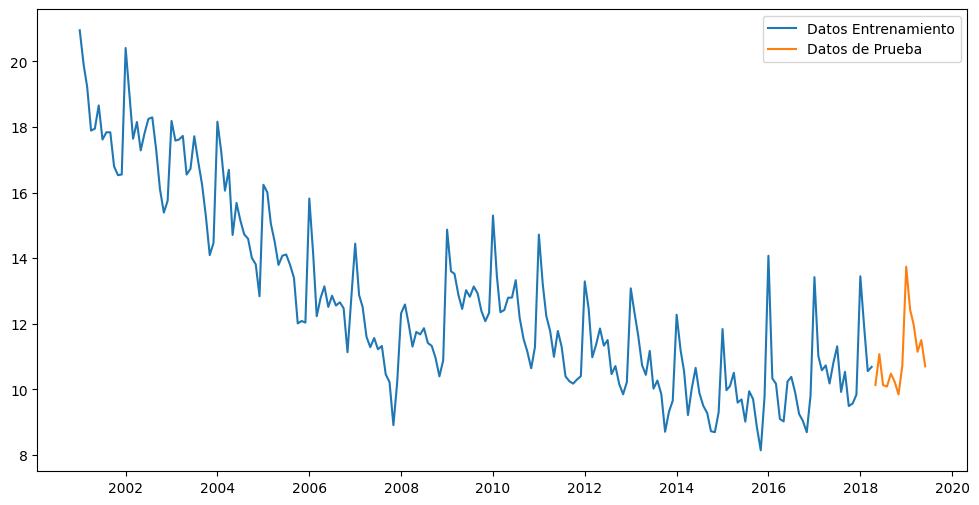

In [50]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

## Personas ocupadas

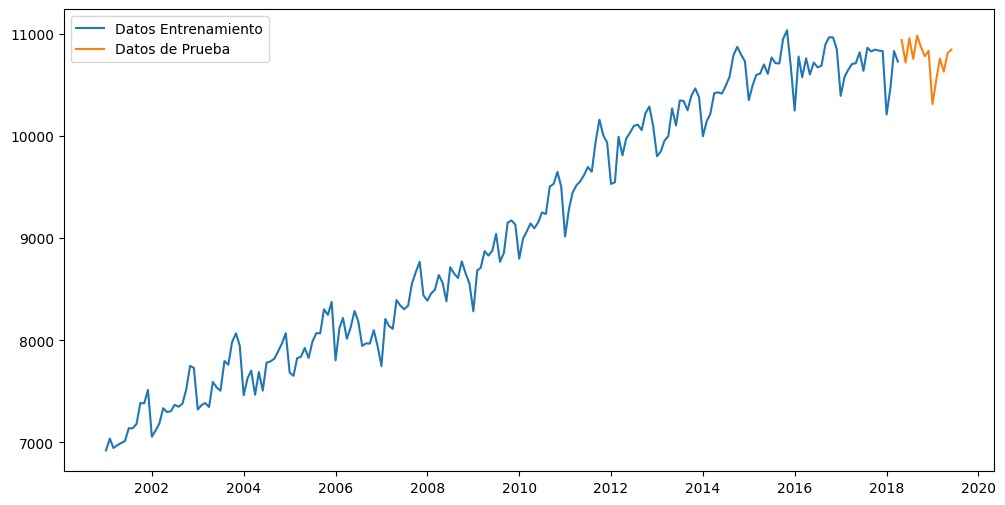

In [51]:
train_len = 208
train_ocupados = data[["Ocupados"]][:train_len]
test_ocupados = data[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados,label="Datos Entrenamiento")
plt.plot(test_ocupados,label="Datos de Prueba")
plt.legend()
plt.show()

In [52]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [53]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


In [54]:
train_ocupados

,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2017-12-01,10834.330
2018-01-01,10212.612
2018-02-01,10476.311


In [55]:
test_ocupados

,Ocupados
mes,
2018-05-01,10941.294
2018-06-01,10720.946
2018-07-01,10959.197
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338
2018-11-01,10783.299
2018-12-01,10835.398
2019-01-01,10314.438


## **5. Promedio movil**

El promedio móvil está dado por:

$$ F_{t + 1}=\frac{Y_{t} + Y_{t-1} + Y_{t-(k-1)} }{ k} $$

El método de los promedios móviles utiliza el promedio de los $k$
valores de datos más recientes en la serie de tiempo como el
pronóstico para el siguiente periodo.

El término móvil indica que, mientras se dispone de una nueva
observación para la serie de tiempo, reemplaza a la observación más
antigua de la ecuación anterior y se calcula un promedio nuevo.
Como resultado, el promedio cambiará, o se moverá, conforme surjan
nuevas observaciones.

$Y_{t}$ = Observación en el período t

$F_{t}$ = Pronóstico en el período t

## Tasa de desempleo

In [56]:
## Considerando el dato actual
ma_2= train_td.rolling(2,min_periods=2).mean()
ma_3= train_td.rolling(3,min_periods=2).mean()
ma_4= train_td.rolling(4,min_periods=2).mean()
ma_5= train_td.rolling(5,min_periods=2).mean()

In [57]:
## Sin considerar el dato actual
ma_2= train_td.shift().rolling(2,min_periods=2).mean()
ma_3= train_td.shift().rolling(3,min_periods=2).mean()
ma_4= train_td.shift().rolling(4,min_periods=2).mean()
ma_5= train_td.shift().rolling(5,min_periods=2).mean()


## personas ocupadas

In [58]:
## Considerando el dato actual
ma_2ocupados= train_ocupados.rolling(2,min_periods=2).mean()
ma_3ocupados= train_ocupados.rolling(3,min_periods=2).mean()
ma_4ocupados= train_ocupados.rolling(4,min_periods=2).mean()
ma_5ocupados= train_ocupados.rolling(5,min_periods=2).mean()

In [59]:
## Sin considerar el dato actual
ma_2ocupados= train_ocupados.shift().rolling(2,min_periods=2).mean()
ma_3ocupados= train_ocupados.shift().rolling(3,min_periods=2).mean()
ma_4ocupados= train_ocupados.shift().rolling(4,min_periods=2).mean()
ma_5ocupados= train_ocupados.shift().rolling(5,min_periods=2).mean()

In [60]:
def fore_ma(datos,w,h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [61]:
ma_2_f= fore_ma(train_td,2,14)
ma_3_f= fore_ma(train_td,3,14)
ma_4_f= fore_ma(train_td,4,14)
ma_5_f= fore_ma(train_td,5,14)

In [62]:
ma_2_focupados= fore_ma(train_ocupados,2,14)
ma_3_focupados= fore_ma(train_ocupados,3,14)
ma_4_focupados= fore_ma(train_ocupados,4,14)
ma_5_focupados= fore_ma(train_ocupados,5,14)

In [63]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


In [64]:
test_ocupados

,Ocupados
mes,
2018-05-01,10941.294
2018-06-01,10720.946
2018-07-01,10959.197
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338
2018-11-01,10783.299
2018-12-01,10835.398
2019-01-01,10314.438


In [65]:
ma_2_f

,TD_13ciudades
mes,
2018-05-01,10.618803
2018-06-01,10.651004
2018-07-01,10.634904
2018-08-01,10.642954
2018-09-01,10.638929
2018-10-01,10.640941
2018-11-01,10.639935
2018-12-01,10.640438
2019-01-01,10.640187


In [85]:
ma_2_focupados

,Ocupados
mes,
2018-05-01,10781.978500
2018-06-01,10755.977750
2018-07-01,10768.978125
2018-08-01,10762.477937
2018-09-01,10765.728031
2018-10-01,10764.102984
2018-11-01,10764.915508
2018-12-01,10764.509246
2019-01-01,10764.712377


In [67]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_td,ma_2_f ))
rmse_ma_3 = np.sqrt(mean_squared_error(test_td,ma_3_f ))
rmse_ma_4 = np.sqrt(mean_squared_error(test_td,ma_4_f ))
rmse_ma_5 = np.sqrt(mean_squared_error(test_td,ma_5_f ))

In [84]:
rmse_ma_2ocupados = np.sqrt(mean_squared_error(test_ocupados,ma_2_focupados ))
rmse_ma_3ocupados = np.sqrt(mean_squared_error(test_ocupados,ma_3_focupados ))
rmse_ma_4ocupados = np.sqrt(mean_squared_error(test_ocupados,ma_4_focupados ))
rmse_ma_5ocupados = np.sqrt(mean_squared_error(test_ocupados,ma_5_focupados ))

In [69]:
print( rmse_ma_2, rmse_ma_3 ,rmse_ma_4 ,rmse_ma_5)

1.1147962992873541 1.079289141194038 1.0913829514823736 1.079379141938296


In [70]:
print( rmse_ma_2ocupados, rmse_ma_3ocupados ,rmse_ma_4ocupados ,rmse_ma_5ocupados)

169.18787998664087 181.43863900870895 212.78442787721826 217.05424156373658


In [87]:
# @title
import pandas as pd

# Crear la tabla
tabla_rmse = pd.DataFrame({
    "Modelo": ["MA(2)", "MA(3)", "MA(4)", "MA(5)"],
    "RMSE TD": [rmse_ma_2, rmse_ma_3, rmse_ma_4, rmse_ma_5],
    "RMSE Ocupados": [rmse_ma_2ocupados, rmse_ma_3ocupados, rmse_ma_4ocupados, rmse_ma_5ocupados]
})

tabla_rmse


,Modelo,RMSE TD,RMSE Ocupados
0,MA(2),1.114796,169.187880
1,MA(3),1.079289,181.438639
2,MA(4),1.091383,212.784428
3,MA(5),1.079379,217.054242


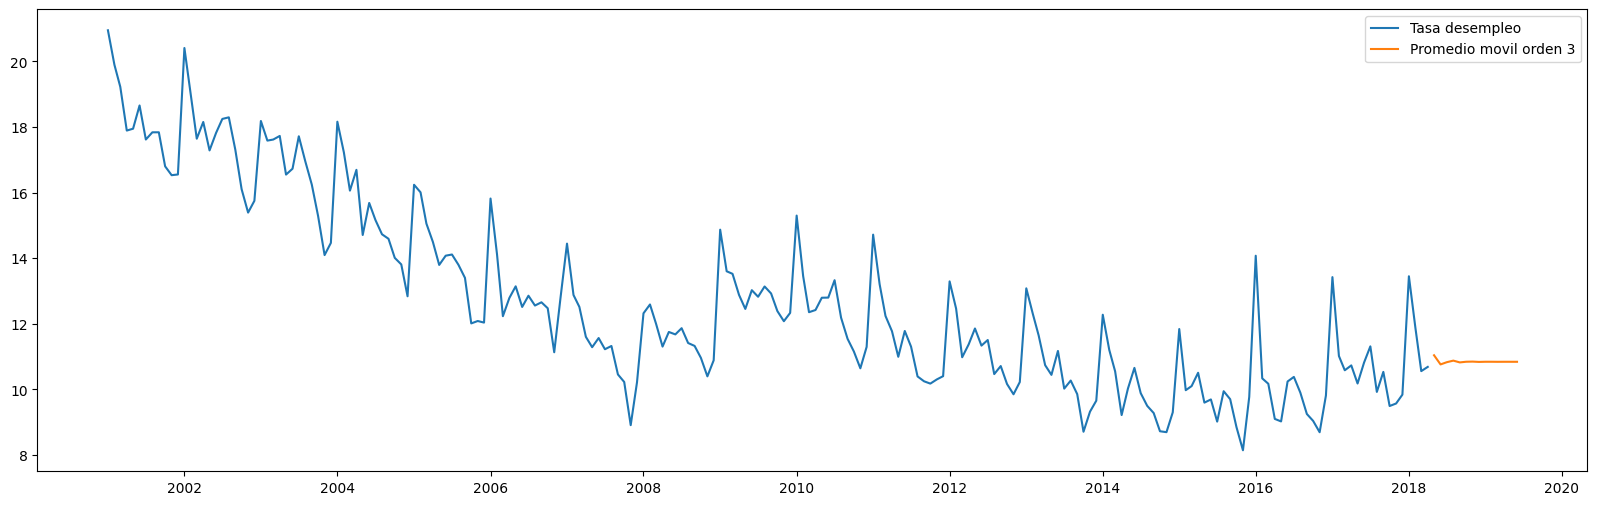

In [71]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_td,label="Tasa desempleo")
plt.plot(ma_3_f,label="Promedio movil orden 3")
plt.legend()
plt.show()

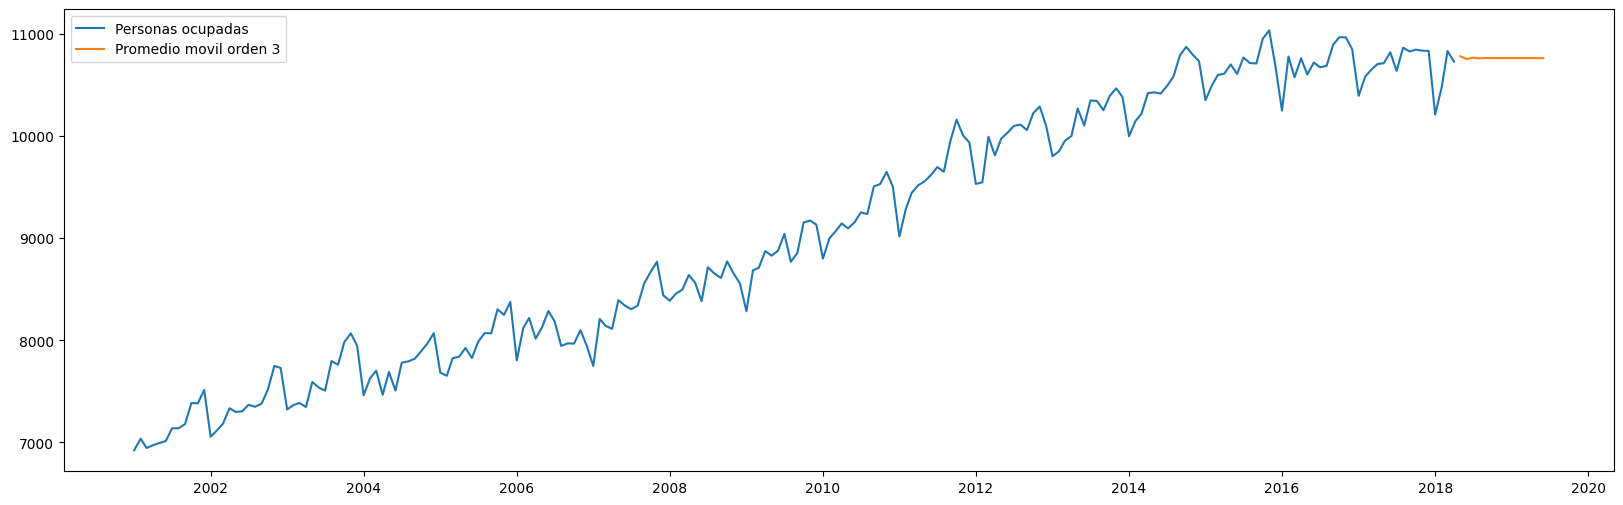

In [72]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_ocupados,label="Personas ocupadas")
plt.plot(ma_2_focupados,label="Promedio movil orden 3")
plt.legend()
plt.show()

Como el mejor valor de RMSE fue con el Promedio móvil con ventana w = 2 realizaremos el pronostico de los siguientes 6 meses usando esta ventana.

In [73]:
pron_ocupados = fore_ma(data["Ocupados"], w=2, h=6)
pron_ocupados

,Ocupados
mes,
2019-07-01,10830.500000
2019-08-01,10839.250000
2019-09-01,10834.875000
2019-10-01,10837.062500
2019-11-01,10835.968750
2019-12-01,10836.515625


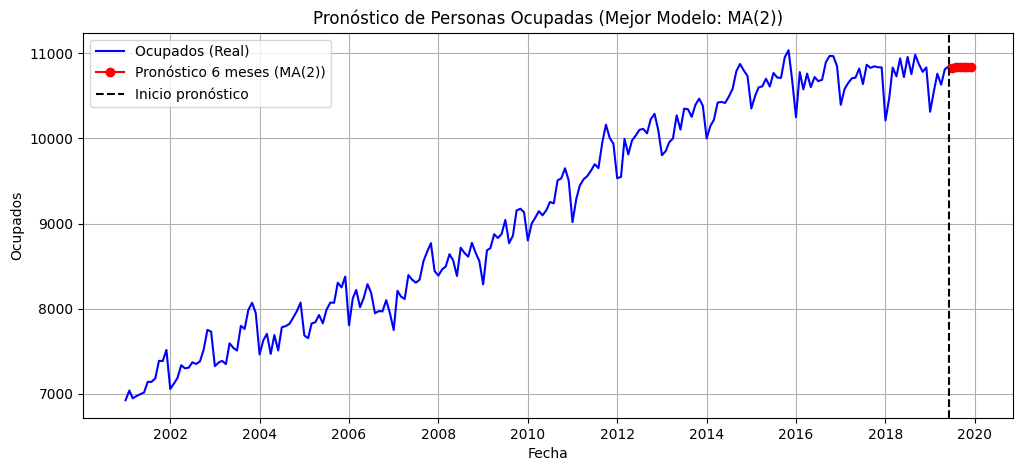

In [74]:
ocupados = data["Ocupados"]
pron_ocupados = fore_ma(ocupados, w=2, h=6)

plt.figure(figsize=(12,5))

# Serie real
plt.plot(ocupados, label="Ocupados (Real)", color="blue")

# Pronóstico
plt.plot(pron_ocupados, label="Pronóstico 6 meses (MA(2))", color="red", marker="o")

# Línea para marcar inicio del pronóstico
plt.axvline(x=ocupados.index[-1], color="black", linestyle="--", label="Inicio pronóstico")

plt.title("Pronóstico de Personas Ocupadas (Mejor Modelo: MA(2))")
plt.xlabel("Fecha")
plt.ylabel("Ocupados")
plt.legend()
plt.grid(True)
plt.show()

Debido a que la curva se suaviza demasiado para w=2 aplicamos Holt-Winters que no solo suaviza los datos, sino que también ajusta un modelo que captura mejor el comportamiento real de la serie, por eso suele generar pronósticos más realistas y con variaciones similares a las observadas en los datos históricos.

In [75]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ajustar Holt-Winters con train
modelo_hw = ExponentialSmoothing(
    train_ocupados,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# Pronóstico sobre el tamaño del test
hw_forecast = modelo_hw.forecast(len(test_ocupados))

# Calcular RMSE
rmse_hw = np.sqrt(mean_squared_error(test_ocupados, hw_forecast))
rmse_hw

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


np.float64(208.80250787357375)

In [76]:
print("RMSE MA(2):", rmse_ma_2ocupados)
print("RMSE Holt-Winters:", rmse_hw)

if rmse_hw < rmse_ma_2ocupados:
    print("Holt-Winters es mejor (menor RMSE).")
else:
    print(" MA(2) es mejor (menor RMSE).")

RMSE MA(2): 169.18787998664087
RMSE Holt-Winters: 208.80250787357375
 MA(2) es mejor (menor RMSE).


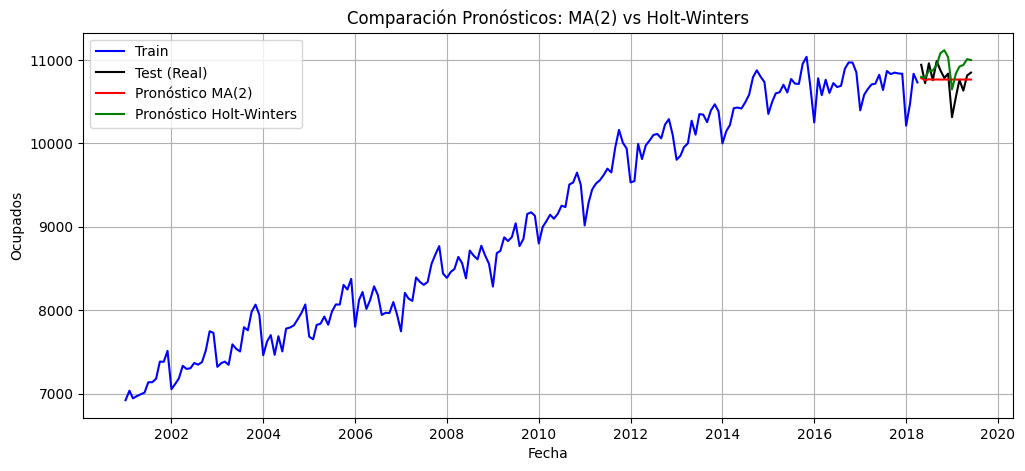

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train_ocupados, label="Train", color="blue")
plt.plot(test_ocupados, label="Test (Real)", color="black")

plt.plot(test_ocupados.index, ma_2_focupados, label="Pronóstico MA(2)", color="red")
plt.plot(hw_forecast, label="Pronóstico Holt-Winters", color="green")

plt.title("Comparación Pronósticos: MA(2) vs Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Ocupados")
plt.legend()
plt.grid(True)
plt.show()

## Pronostico para los 6 meses siguientes

## Con dos ventanas  

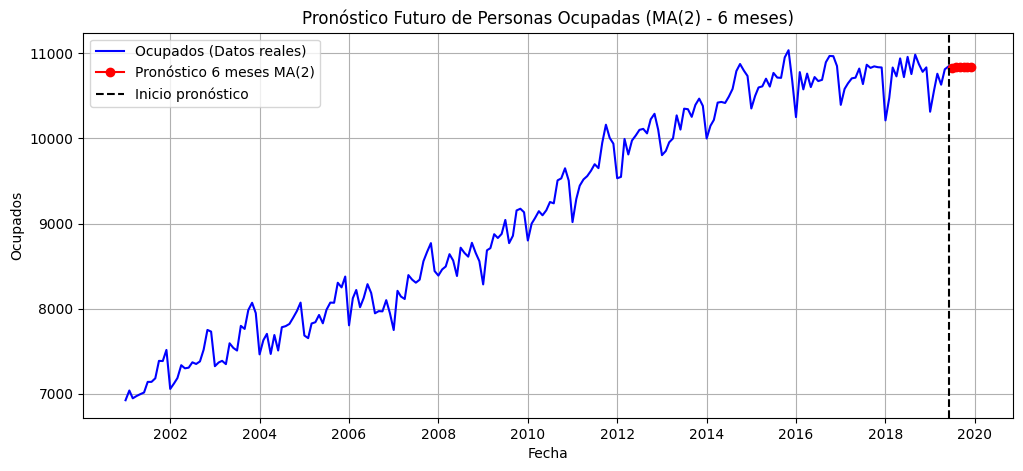

In [78]:
ocupados_total = data["Ocupados"]

# Pronóstico MA(2) 6 meses después del último dato
forecast_ma2 = fore_ma(ocupados_total, w=2, h=6)

# Gráfica
plt.figure(figsize=(12,5))

plt.plot(ocupados_total, label="Ocupados (Datos reales)", color="blue")
plt.plot(forecast_ma2, label="Pronóstico 6 meses MA(2)", color="red", marker="o")

plt.axvline(x=ocupados_total.index[-1], color="black", linestyle="--", label="Inicio pronóstico")

plt.title("Pronóstico Futuro de Personas Ocupadas (MA(2) - 6 meses)")
plt.xlabel("Fecha")
plt.ylabel("Ocupados")
plt.legend()
plt.grid(True)
plt.show()

## Últimos 24 meses

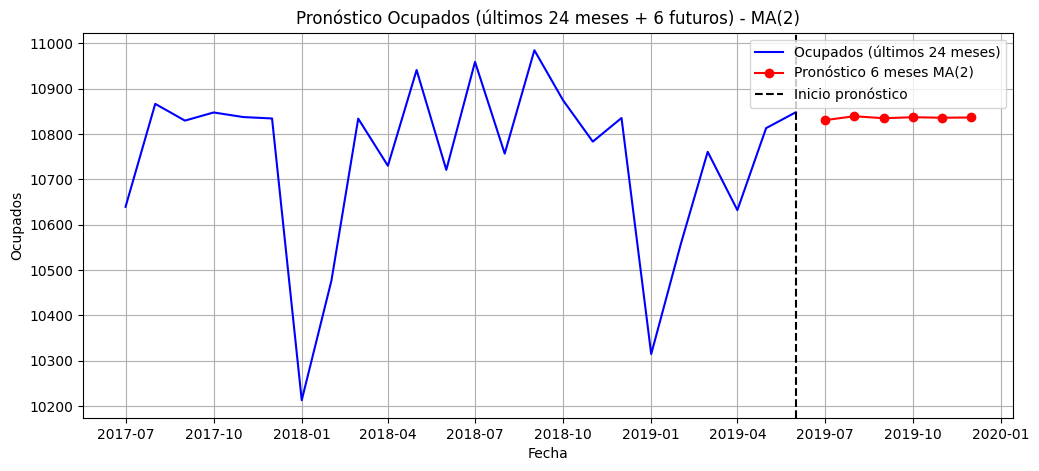

In [79]:
plt.figure(figsize=(12,5))

plt.plot(ocupados_total[-24:], label="Ocupados (últimos 24 meses)", color="blue")
plt.plot(forecast_ma2, label="Pronóstico 6 meses MA(2)", color="red", marker="o")

plt.axvline(x=ocupados_total.index[-1], color="black", linestyle="--", label="Inicio pronóstico")

plt.title("Pronóstico Ocupados (últimos 24 meses + 6 futuros) - MA(2)")
plt.xlabel("Fecha")
plt.ylabel("Ocupados")
plt.legend()
plt.grid(True)
plt.show()

## Holt-Winters

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


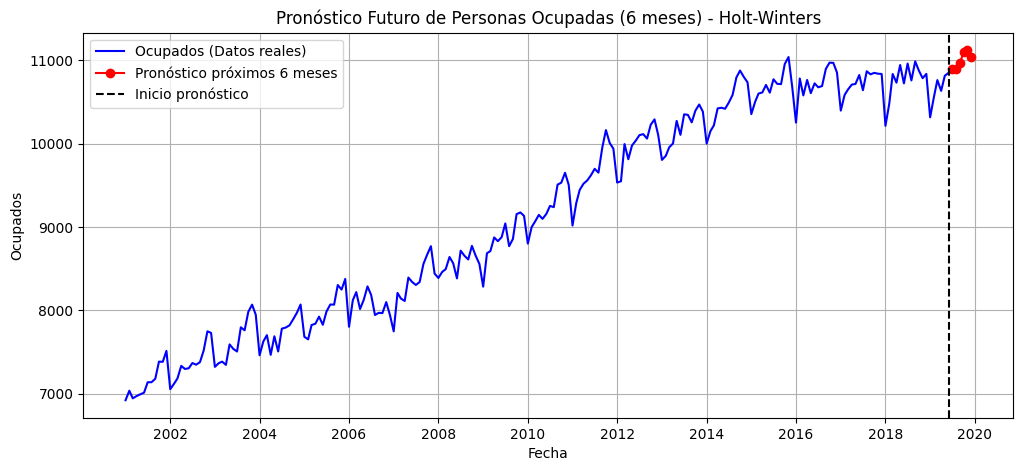

In [81]:
# Usamos TODOS los datos disponibles (train + test)
serie_total = data["Ocupados"]

# Ajustamos el modelo con toda la serie
modelo_final = ExponentialSmoothing(
    serie_total,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# Pronosticamos 6 meses después del último dato
forecast_6 = modelo_final.forecast(6)

# Graficamos: datos reales + pronóstico futuro
plt.figure(figsize=(12,5))

plt.plot(serie_total, label="Ocupados (Datos reales)", color="blue")
plt.plot(forecast_6, label="Pronóstico próximos 6 meses", color="red", marker="o")

# Línea para marcar inicio del pronóstico
plt.axvline(x=serie_total.index[-1], color="black", linestyle="--", label="Inicio pronóstico")

plt.title("Pronóstico Futuro de Personas Ocupadas (6 meses) - Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Ocupados")
plt.legend()
plt.grid(True)
plt.show()

## Últimos 24 meses

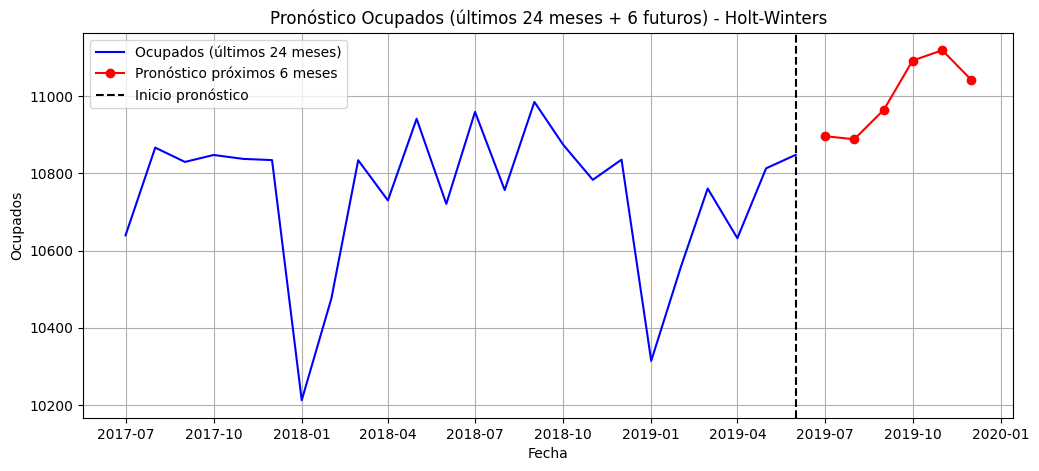

In [82]:
plt.figure(figsize=(12,5))

plt.plot(serie_total[-24:], label="Ocupados (últimos 24 meses)", color="blue")
plt.plot(forecast_6, label="Pronóstico próximos 6 meses", color="red", marker="o")

plt.axvline(x=serie_total.index[-1], color="black", linestyle="--", label="Inicio pronóstico")

plt.title("Pronóstico Ocupados (últimos 24 meses + 6 futuros) - Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Ocupados")
plt.legend()
plt.grid(True)
plt.show()

## **6. Ejercicio**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.